De forma similar a como lo hicimos con el modelo SIR, es posible compactificar el codigo para el modelo DPM. Teniendo en cuenta las reducciones que este tiene: (iota=0, C0) --> DP(Competencia), (iota, C0=0) --> DP(Carga Ambiental) y (iota=0, C0=0) --> DP(Básico).

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

#Constantes del modelo depredador-presa
nu = 1 #Tasa de crecimiento de presas
mu = 0.02 #Tasa de caza de presas por depredadores 1
kappa = 0.018 #Tasa de caza de presas por depredadores 2
iota = 0.001 #Carga ambiental de presas

delta = 0.4 #Tasa de mortalidad de depredadores 1
alpha = 0.01 #Tasa de reproducción de depredadores 1 por consumo de presas

Delta = 0.36 #Tasa de mortalidad de depredadores 2
beta = 0.01 #Tasa de reproducción de depredadores 2 por consumo de presas

P0 = 120 #Población inicial de presas
D0 = 10 #Pobalción inicial de depredadores 1
C0 = 10 #Población inicial de depredadores 2
dias = 365 #Tiempo de simulación

Escribimos el sistema de ED del modelo DPM.

In [ ]:
#Sistema de ED del DPM
def DP(t, y, P, D, C, nu, mu, kappa, iota, delta, alpha, Delta, beta):
    P, D, C = y
    
    dP = P * (nu - (mu * D + kappa * C  + iota * P))
    dD = D * ((alpha * P) - delta)
    dC = C * ((beta * P) - Delta)
    return dP, dD, dC

Separamos de forma uniforme el paso del tiempo y usamos la función solve_ivp para resolver el sistema de ED de DPM haciendo uso del metodo Rungen-Kutta 4 (RK45).

In [21]:
#Resolución del sistema de ED utilizando solve_ivp
t_eval = np.linspace(0, dias, 2000)

sol = solve_ivp(DP, (0, dias), [P0, D0, C0], args=(P0, D0, C0, nu, mu, kappa, iota, delta, alpha, Delta, beta), t_eval=t_eval, method='RK45')
P, D, C = sol.y
t = sol.t

Finalmente obtenemos P, D y C como una evolución temporal continua bajo el sistema de ED del modelo DPM.

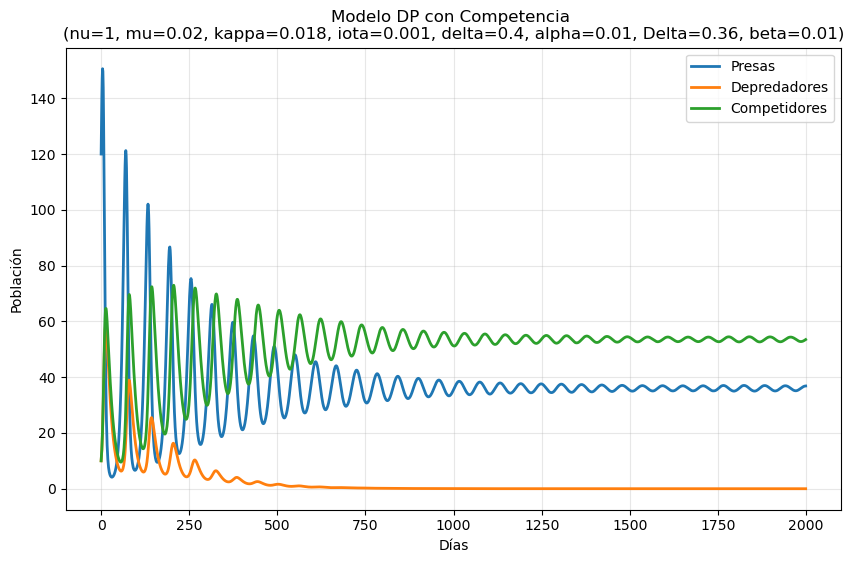

In [22]:
#Gráfica de resultados
plt.figure(figsize=(10,6))
plt.plot(P, label='Presas', linewidth=2)
plt.plot(D, label='Depredadores', linewidth=2)
plt.plot(C, label='Competidores', linewidth=2)
plt.xlabel('Días')
plt.ylabel('Población')
plt.title('Modelo DP con Competencia \n(nu={}, mu={}, kappa={}, iota={}, delta={}, alpha={}, Delta={}, beta={})'.format(nu, mu, kappa, iota, delta, alpha, Delta, beta))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Recuperando un resultado similar al obtenido de forma "manual".

Referencias:

-[Detalles en la funcionalidad de scipy.integrate](https://docs.scipy.org/doc/scipy/tutorial/integrate.html)

-[Metodo Runge-Kutta](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods)

-[Runge-Kutta 4,5 (RK45)](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta%E2%80%93Fehlberg_method)
